In [46]:
import numpy as np
import pandas as pd
from scipy.special import logsumexp
from scipy.optimize import minimize
import matplotlib.pyplot as plt

Part 0: Pre-Estimation

In [3]:
df = pd.read_csv('rust_data_2020.csv', index_col=0)
df = df.sort_values(['bus_id', 'period_id']).reset_index(drop=True)

In [4]:
df

,period_id,y_it,x_it,bus_id
0,0,0,0,0
1,1,0,1,0
2,2,0,3,0
3,3,0,4,0
4,4,0,6,0
...,...,...,...,...
7495,145,1,1,49
7496,146,0,2,49
7497,147,0,4,49
7498,148,0,5,49


Q 0.1

In [16]:
# Construct lagged mileage and mileage increment
df["x_lag"] = df.groupby("bus_id")["x_it"].shift(1)
df["dx"] = df["x_it"] - df["x_lag"]

In [19]:
# Keep observations with no replacement and valid lagged mileage
sub = df[(df["y_it"] == 0) & (df["x_lag"].notna())].copy()
sub["dx"] = sub["dx"].astype(int)

# Check the support of mileage increments
print(sub["dx"].value_counts().sort_index())

dx
0     650
1    3125
2    3322
3      77
Name: count, dtype: int64


In [20]:
# Estimate transition probabilities
dx_support = np.arange(5)

counts = sub["dx"].value_counts().reindex(dx_support, fill_value=0).sort_index()
pi = counts / counts.sum()

pi_table = pd.DataFrame({
    "dx": dx_support,
    "count": counts.values,
    "probability": pi.values
})

In [21]:
pi_table

,dx,count,probability
0,0,650,0.090605
1,1,3125,0.435601
2,2,3322,0.463061
3,3,77,0.010733
4,4,0,0.000000


Q 0.2

In [23]:
# State space
n_states = 201
max_x = n_states - 1

In [24]:
# Initialize transition matrix
P = np.zeros((n_states, n_states))

# Fill transition matrix
for x in range(n_states):
    for dx, prob in zip(dx_support, pi.values):
        x_next = min(x + dx, max_x)
        P[x, x_next] += prob

# Check row sums
row_sums = P.sum(axis=1)

print("Transition matrix shape:", P.shape)
print("Minimum row sum:", row_sums.min())
print("Maximum row sum:", row_sums.max())
print("All rows sum to one:", np.allclose(row_sums, 1.0))

Transition matrix shape: (201, 201)
Minimum row sum: 0.9999999999999999
Maximum row sum: 1.0
All rows sum to one: True


In [26]:
P_df = pd.DataFrame(
    P,
    index=[f"x={x}" for x in range(n_states)],
    columns=[f"x_next={x}" for x in range(n_states)]
)

In [27]:
P_df.iloc[:10, :15]

,x_next=0,x_next=1,x_next=2,x_next=3,x_next=4,x_next=5,x_next=6,x_next=7,x_next=8,x_next=9,x_next=10,x_next=11,x_next=12,x_next=13,x_next=14
x=0,0.090605,0.435601,0.463061,0.010733,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
x=1,0.000000,0.090605,0.435601,0.463061,0.010733,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
x=2,0.000000,0.000000,0.090605,0.435601,0.463061,0.010733,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
x=3,0.000000,0.000000,0.000000,0.090605,0.435601,0.463061,0.010733,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
x=4,0.000000,0.000000,0.000000,0.000000,0.090605,0.435601,0.463061,0.010733,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
x=5,0.000000,0.000000,0.000000,0.000000,0.000000,0.090605,0.435601,0.463061,0.010733,0.000000,0.000000,0.000000,0.000000,0.0,0.0
x=6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.090605,0.435601,0.463061,0.010733,0.000000,0.000000,0.000000,0.0,0.0
x=7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.090605,0.435601,0.463061,0.010733,0.000000,0.000000,0.0,0.0
x=8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.090605,0.435601,0.463061,0.010733,0.000000,0.0,0.0
x=9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.090605,0.435601,0.463061,0.010733,0.0,0.0


Part 1:  Estimation via NFXP

Q 1.1

For a given parameter vector $\theta = (\theta_1, RC)$, we solve for $EV(x,\theta)$ via fixed-point iteration. The per-period payoffs are
$$
u(x, 0) = -\theta_1 x, \qquad u(x, 1) = -RC,
$$
and the choice-specific value functions are
$$
v_0(x) = -\theta_1 x + \beta \sum_{x'} P(x' \mid x,\, y=0)\, EV(x'),
\qquad
v_1(x) = -RC + \beta \sum_{x'} P(x' \mid 0,\, y=0)\, EV(x').
$$
Under the Type-I Extreme Value assumption, integrating out the private shocks yields the fixed-point equation
$$
EV(x) = \log\!\left[\exp(v_0(x)) + \exp(v_1(x))\right],
$$
which we solve by iterating $EV^{(k+1)} = \mathcal{T}(EV^{(k)},\theta)$ until $\|EV^{(k+1)} - EV^{(k)}\|_\infty < 10^{-10}$.

In [29]:
def solve_ev(theta, P, beta=0.95, tol=1e-10, max_iter=10_000):
    theta_1, RC = theta
    n_states = P.shape[0]
    x_grid = np.arange(n_states)

    EV = np.zeros(n_states)

    for it in range(max_iter):
        cont_keep = P @ EV
        cont_replace = P[0, :] @ EV

        v_keep = -theta_1 * x_grid + beta * cont_keep
        v_replace = -RC + beta * cont_replace * np.ones(n_states)

        EV_new = logsumexp(
            np.column_stack([v_keep, v_replace]),
            axis=1
        )

        diff = np.max(np.abs(EV_new - EV))

        EV = EV_new

        if diff < tol:
            break

    return EV

In [30]:
theta0 = np.array([0.01, 5.0])

EV = solve_ev(theta0, P, beta=0.95)

print("EV shape:", EV.shape)
print("First 10 EV values:")
print(np.round(EV[:10], 6))

EV shape: (201,)
First 10 EV values:
[-3.011244 -3.130859 -3.248094 -3.362925 -3.475333 -3.585301 -3.692818
 -3.797875 -3.90047  -4.000602]


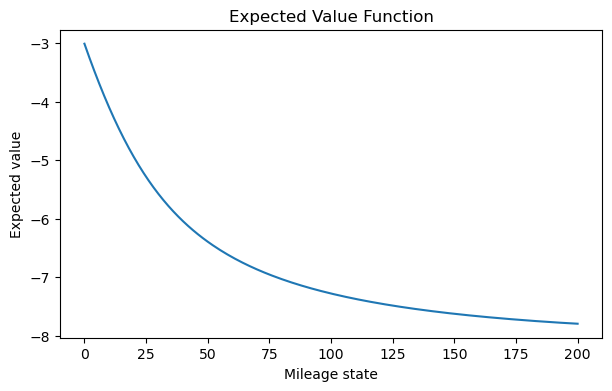

In [31]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(len(EV)), EV)
plt.xlabel("Mileage state")
plt.ylabel("Expected value")
plt.title("Expected Value Function")
plt.show()

Q 1.2

Given $EV(x,\theta)$ from Q 1.1, the conditional choice probabilities follow from the logit formula:
$$
\Pr(y=0 \mid x;\,\theta) = \frac{\exp(v_0(x))}{\exp(v_0(x)) + \exp(v_1(x))},
\qquad
\Pr(y=1 \mid x;\,\theta) = \frac{\exp(v_1(x))}{\exp(v_0(x)) + \exp(v_1(x))}.
$$
We compute these for all $x \in \{0, \ldots, 200\}$.

In [32]:
def get_ccp(theta, EV, P, beta=0.95):
    theta_1, RC = theta
    n_states = P.shape[0]
    x_grid = np.arange(n_states)

    cont_keep = P @ EV
    cont_replace = P[0, :] @ EV

    v_keep = -theta_1 * x_grid + beta * cont_keep
    v_replace = -RC + beta * cont_replace * np.ones(n_states)

    log_denom = logsumexp(
        np.column_stack([v_keep, v_replace]),
        axis=1
    )

    p_keep = np.exp(v_keep - log_denom)
    p_replace = np.exp(v_replace - log_denom)

    ccp = pd.DataFrame({
        "x": x_grid,
        "p_keep": p_keep,
        "p_replace": p_replace
    })

    return ccp

In [34]:
theta0 = np.array([0.01, 5.0])

EV = solve_ev(theta0, P, beta=0.95)

ccp = get_ccp(theta0, EV, P, beta=0.95)

In [35]:
ccp

,x,p_keep,p_replace
0,0,0.993307,0.006693
1,1,0.992457,0.007543
2,2,0.991518,0.008482
3,3,0.990486,0.009514
4,4,0.989355,0.010645
...,...,...,...
196,196,0.207210,0.792790
197,197,0.205207,0.794793
198,198,0.203251,0.796749
199,199,0.201470,0.798530


Q 1.3

The log-likelihood contribution of a single observation $(x_{it}, y_{it})$ is
$$
\ell_{it}(\theta) = y_{it}\log\Pr(y=1\mid x_{it};\theta) + (1-y_{it})\log\Pr(y=0\mid x_{it};\theta).
$$
For every mileage state $x$, define the per-state likelihood contributions
$$
L_0(x;\theta) = \log\Pr(y=0\mid x;\theta), \qquad L_1(x;\theta) = \log\Pr(y=1\mid x;\theta).
$$
Since $EV(x,\theta)$ has no closed-form derivative with respect to $\theta$ (it is defined implicitly via the fixed point), we approximate the gradient by finite differences:
$$
\frac{\partial L_j(x;\theta)}{\partial \theta_k} \approx \frac{L_j(x;\theta + h\,e_k) - L_j(x;\theta - h\,e_k)}{2h}, \quad h = 10^{-5},
$$
where $e_k$ is the $k$-th unit vector and $j \in \{0,1\}$.

In [36]:
def log_lik_and_grad(theta, P, beta=0.95, h=1e-5):
    def get_log_p(t):
        ev  = solve_ev(t, P, beta)
        ccp = get_ccp(t, ev, P, beta)
        return np.column_stack([np.log(ccp['p_keep']), np.log(ccp['p_replace'])])

    log_p = get_log_p(theta)

    n_params = len(theta)
    grad = np.zeros((P.shape[0], 2, n_params))

    for k in range(n_params):
        t_up = theta.copy(); t_up[k] += h
        t_dn = theta.copy(); t_dn[k] -= h
        grad[:, :, k] = (get_log_p(t_up) - get_log_p(t_dn)) / (2 * h)

    return log_p, grad


In [37]:
theta0 = np.array([0.01, 5.0])
log_p, grad = log_lik_and_grad(theta0, P)

In [40]:
print("log P(y=0|x), log P(y=1|x):")
print(np.round(log_p, 6))

log P(y=0|x), log P(y=1|x):
[[-0.006715 -5.006715]
 [-0.007572 -4.8871  ]
 [-0.008518 -4.769865]
 [-0.009559 -4.655034]
 [-0.010702 -4.542626]
 [-0.011954 -4.432658]
 [-0.01332  -4.325141]
 [-0.014806 -4.220084]
 [-0.016419 -4.117489]
 [-0.018164 -4.017356]
 [-0.020047 -3.91968 ]
 [-0.022072 -3.82445 ]
 [-0.024245 -3.731654]
 [-0.026569 -3.641272]
 [-0.029048 -3.553284]
 [-0.031687 -3.467663]
 [-0.034487 -3.38438 ]
 [-0.037451 -3.303402]
 [-0.04058  -3.224693]
 [-0.043877 -3.148216]
 [-0.047342 -3.073928]
 [-0.050976 -3.001787]
 [-0.054777 -2.931746]
 [-0.058746 -2.863759]
 [-0.062882 -2.797776]
 [-0.067182 -2.733749]
 [-0.071646 -2.671627]
 [-0.076271 -2.611358]
 [-0.081054 -2.55289 ]
 [-0.085993 -2.496173]
 [-0.091085 -2.441155]
 [-0.096327 -2.387783]
 [-0.101715 -2.336007]
 [-0.107246 -2.285778]
 [-0.112915 -2.237043]
 [-0.11872  -2.189756]
 [-0.124657 -2.143868]
 [-0.130722 -2.099332]
 [-0.136911 -2.056102]
 [-0.143219 -2.014134]
 [-0.149644 -1.973383]
 [-0.156182 -1.933808]
 [-0.1

In [44]:
print("\nGradient w.r.t. theta_1:")
print(np.round(grad[:5, :, 0], 6))



Gradient w.r.t. theta_1:
[[-0.        0.      ]
 [-0.068967  9.073851]
 [-0.152163 17.788355]
 [-0.251077 26.140337]
 [-0.367212 34.127611]]


In [45]:
print("\nGradient w.r.t. RC:")
print(np.round(grad[:5, :, 1], 6))


Gradient w.r.t. RC:
[[ 0.006693 -0.993307]
 [ 0.007402 -0.973844]
 [ 0.008162 -0.954171]
 [ 0.008974 -0.934318]
 [ 0.009838 -0.914317]]


Q 1.4

The total log-likelihood over all observations is
$$
\ell(\theta) = \sum_{i}\sum_{t} \ell_{it}(\theta)
= \sum_{i}\sum_{t} \left[ y_{it}\, L_1(x_{it};\theta) + (1-y_{it})\, L_0(x_{it};\theta) \right],
$$
and its gradient is
$$
\frac{\partial \ell(\theta)}{\partial \theta_k}
= \sum_{i}\sum_{t} \left[ y_{it}\, \frac{\partial L_1(x_{it};\theta)}{\partial \theta_k}
+ (1-y_{it})\, \frac{\partial L_0(x_{it};\theta)}{\partial \theta_k} \right].
$$
We maximize $\ell(\theta)$

In [51]:
def neg_loglik(theta, P, beta=0.95):
    log_p, grad = log_lik_and_grad(theta, P, beta)

    # decision state = lagged mileage; drop t=0 of each bus
    df_v = df.dropna(subset=['x_lag']).copy()
    s_idx = df_v['x_lag'].values.astype(int)
    y     = df_v['y_it'].values

    ll = np.sum(y * log_p[s_idx, 1] + (1 - y) * log_p[s_idx, 0])
    g  = np.sum(
        y[:, None]       * grad[s_idx, 1, :]
      + (1 - y)[:, None] * grad[s_idx, 0, :],
        axis=0
    )
    return -ll, -g

In [52]:
theta0 = np.array([0.01, 5.0])

result = minimize(
    neg_loglik,
    theta0,
    args=(P,),
    method='L-BFGS-B',
    jac=True,
    bounds=[(1e-6, None), (1e-6, None)],
    options={'disp': True, 'ftol': 1e-12, 'gtol': 1e-6}
)

theta_hat = result.x

In [53]:
print(f"\nEstimated theta_1 : {theta_hat[0]:.6f}")
print(f"Estimated RC      : {theta_hat[1]:.6f}")
print(f"Log-likelihood    : {-result.fun:.4f}")
print(f"Converged         : {result.success}")


Estimated theta_1 : 0.031405
Estimated RC      : 11.657763
Log-likelihood    : -862.0492
Converged         : True
